$$
\begin{aligned}
& \textbf{1. MÔ HÌNH TOÁN HỌC CỦA BAG-OF-WORDS (BoW)} \\
\\
& \text{Cho tập dữ liệu văn bản (Corpus) gồm } m \text{ câu:} \\
& \mathcal{C} = \{S_1, S_2, \dots, S_m\} \\
\\
& \text{Từ điển (Vocabulary) } V \text{ chứa các từ duy nhất và được sắp xếp:} \\
& V = \text{sort}\left( \bigcup_{S \in \mathcal{C}} \text{split}(S) \right), \quad \text{Kích thước: } |V| = n \\
\\
& \text{Mỗi câu } S \text{ được ánh xạ thành vector đặc trưng } \mathbf{x} \in \mathbb{R}^{n}: \\
& \mathbf{x} = \begin{bmatrix} x_1, x_2, \dots, x_n \end{bmatrix}^T, \quad \text{với } x_i = \text{count}(w_i, S) \\
\\
\hline \\
& \textbf{2. GIẢI PHẪU CÚ PHÁP PYTHON (COMPREHENSION)} \\
\\
& \text{Cú pháp: } \texttt{vocab = sorted(\{w for s in cau for w in s.lower().split()\})} \\
\\
& \bullet \textbf{ Thứ tự vòng lặp lồng nhau (Nested Loops):} \\
& \underbrace{w}_{\text{Lấy từ } w} \quad \underbrace{\text{for } s \text{ in cau}}_{\text{Duyệt câu } s \in \mathcal{C}} \quad \underbrace{\text{for } w \text{ in } s.\text{split}()}_{\text{Duyệt từ } w \in S} \\
\\
& \bullet \textbf{ Tại sao dùng Set } \{ \dots \} \text{?} \rightarrow \textbf{Lọc trùng lặp (Uniqueness)} \\
& \text{Loại bỏ các phần tử lặp lại để tạo không gian đặc trưng duy nhất:} \\
& \{w_1, w_2, w_1\} \xrightarrow{\text{Set}} \{w_1, w_2\} \\
\\
& \bullet \textbf{ Tại sao dùng } \texttt{sorted()} \text{?} \rightarrow \textbf{Tính nhất quán (Consistency)} \\
& \text{Set không có thứ tự } \xrightarrow{\texttt{sorted()}} \text{ List có thứ tự cố định (A-Z)} \\
& \text{(Đảm bảo vector } \mathbf{x} \text{ luôn ánh xạ đúng vị trí index để AI có thể học)}
\end{aligned}
$$

In [1]:
import numpy as np

# ===== Neu chon TEXT (bag-of-words) =====
# Giả sử ta có một danh sách các câu (corpus)
cau = [
    "You are my fire",
    "The one desire",
    "Believe when I say",
    "I want it that way",
    "But we are two worlds apart",
    "Can't reach to your heart",
    "When you say",
    "That I want it that way"
]

# create vocab with each have only one word.
vocab = sorted({w for s in cau for w in s.lower().split()})

print("Từ điển (vocab):", vocab) #data prepresentation
print(type(vocab)) # type of data
print(vocab.index('fire')) # will print out index 6
print(f"function of lower and split {cau[0].lower().split()}")


Từ điển (vocab): ['apart', 'are', 'believe', 'but', "can't", 'desire', 'fire', 'heart', 'i', 'it', 'my', 'one', 'reach', 'say', 'that', 'the', 'to', 'two', 'want', 'way', 'we', 'when', 'worlds', 'you', 'your']
<class 'list'>
6
function of lower and split ['you', 'are', 'my', 'fire']


# ex01

## 1.) Biến dữ liệu thành ma trận

Tạo ma trận X: với text là (số câu × số từ)

In [2]:
# 2. Hàm biến đổi 1 câu thành 1 vector số
def to_vector(s):
    n = np.zeros(len(vocab)) #create an array with the length of vocal with each elements at each index = 0
    for w in s.lower().split():
        if w in vocab:  # <--- DÒNG BẢO KÊ: Có trong từ điển mới làm việc!
            n[vocab.index(w)] += 1
    return n
        

# 3. Biến đổi toàn bộ danh sách câu thành Ma trận X
X = np.array([to_vector(s) for s in cau])

print("Ma trận X:\n", X)
print("Kích thước X:", X.shape, "-> (số câu, số từ)")       # (so_cau, so_tu)

Ma trận X:
 [[0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0.
  0.]
 [1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0.
  0.]
 [0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
  1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1.
  0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 2. 0. 0. 0. 1. 1. 0. 0. 0. 0.
  0.]]
Kích thước X: (8, 25) -> (số câu, số từ)


hàng đại diện cho số câu của toàn bộ text, còn 25 là số từ độc lập của toàn bộ text.

Đối với ma trận X có kích thước (số câu, số từ): 
Mỗi HÀNG (Row) đại diện cho: Một mẫu dữ liệu (ở đây là 1 câu văn/câu hát).
Mỗi CỘT (Column) đại diện cho: Một đặc trưng (ở đây là 1 từ vựng duy nhất trong từ điển vocab).
Giá trị tại ô 
(i,j): Là số lần (tần suất) cái từ vựng thứ j
 xuất hiện trong câu thứ i.

## 2). Phép toán cơ bản. Tính vector trung bình theo cột, trừ trung bình (broadcasting); in shape trước/sau để minh họa quy tắc broadcasting.

In [3]:
mean_v = X.mean(axis = 0)
print(mean_v)

print(f"shape of mean_v vector {mean_v.shape}")
print(f"shape of X before broadcasting: {X.shape}")
X_new = X - mean_v
print(f"X after broadcasting:\n {X_new}")
print(f"X shape after broadcasting: {X_new.shape}")

[0.125 0.25  0.125 0.125 0.125 0.125 0.125 0.125 0.375 0.25  0.125 0.125
 0.125 0.25  0.375 0.125 0.125 0.125 0.25  0.25  0.125 0.25  0.125 0.25
 0.125]
shape of mean_v vector (25,)
shape of X before broadcasting: (8, 25)
X after broadcasting:
 [[-0.125  0.75  -0.125 -0.125 -0.125 -0.125  0.875 -0.125 -0.375 -0.25
   0.875 -0.125 -0.125 -0.25  -0.375 -0.125 -0.125 -0.125 -0.25  -0.25
  -0.125 -0.25  -0.125  0.75  -0.125]
 [-0.125 -0.25  -0.125 -0.125 -0.125  0.875 -0.125 -0.125 -0.375 -0.25
  -0.125  0.875 -0.125 -0.25  -0.375  0.875 -0.125 -0.125 -0.25  -0.25
  -0.125 -0.25  -0.125 -0.25  -0.125]
 [-0.125 -0.25   0.875 -0.125 -0.125 -0.125 -0.125 -0.125  0.625 -0.25
  -0.125 -0.125 -0.125  0.75  -0.375 -0.125 -0.125 -0.125 -0.25  -0.25
  -0.125  0.75  -0.125 -0.25  -0.125]
 [-0.125 -0.25  -0.125 -0.125 -0.125 -0.125 -0.125 -0.125  0.625  0.75
  -0.125 -0.125 -0.125 -0.25   0.625 -0.125 -0.125 -0.125  0.75   0.75
  -0.125 -0.25  -0.125 -0.25  -0.125]
 [ 0.875  0.75  -0.125  0.875 -0.12

$$
\begin{aligned}
& \textbf{8. TẠI SAO PHẢI TRỪ TRUNG BÌNH (MEAN CENTERING)?} \\
\\
& \textbf{a. Làm nổi bật phương sai (Highlight Variance):} \\
& \text{Dời trọng tâm dữ liệu về gốc tọa độ } (0,0) \text{. Giúp mô hình AI ngừng quan tâm} \\
& \text{đến các giá trị nền (background values) và chỉ tập trung học sự khác biệt.} \\
\\
& \textbf{b. Tối ưu hóa (Optimization):} \\
& \text{Giúp không gian hàm mất mát (Loss Landscape) trở nên đối xứng hơn,} \\
& \text{từ đó thuật toán Gradient Descent hội tụ (học) nhanh và ổn định hơn.} \\
\\
& \textbf{c. Mở rộng thang đo Cosine (Pearson Correlation):} \\
& \text{Khi } \mathbf{X} \text{ được chuẩn hóa Zero-mean, phép tính Cosine Similarity} \\
& \text{sẽ tương đương với Hệ số tương quan Pearson:} \\
& \text{Pearson}(\mathbf{x}, \mathbf{y}) = \frac{(\mathbf{x} - \bar{\mathbf{x}}) \cdot (\mathbf{y} - \bar{\mathbf{y}})}{||\mathbf{x} - \bar{\mathbf{x}}||_2 \times ||\mathbf{y} - \bar{\mathbf{y}}||_2} \quad \in [-1, 1] \\
& \rightarrow \text{Cho phép mô hình đánh giá được sự "đối lập / ngược pha" (khi điểm } < 0 \text{).}
\end{aligned}
$$

## 3) Cosine similarity. Hoàn thiện hàm cosine_similarity(X, Y=None) cho batch (chuẩn hóa theo hàng, keepdims=True), trả về ma trận tương đồng.

In [4]:
def cosine_similarity (X , Y = None ) :
    if Y is None :
        Y = X
    Xn = X / np. linalg . norm (X , axis =1 , keepdims = True )
    Yn = Y / np . linalg . norm (Y , axis =1 , keepdims = True )
    return Xn @ Yn . T



## 4) Truy vấn. Viết hàm search(query, top_k=3) trả về top_k mục giống truy vấn nhất kèm điểm cosine.

$$
\begin{aligned}
& \textbf{THUẬT TOÁN TRUY VẤN TÌM KIẾM (SEARCH ALGORITHM)} \\
\\
& \textbf{1. Đầu vào (Input):} \\
& \bullet \text{Câu truy vấn: } q \text{ (Ví dụ: "I want fire")} \\
& \bullet \text{Ma trận dữ liệu: } \mathbf{X} \in \mathbb{R}^{m \times n} \text{ (} m \text{ câu, } n \text{ từ vựng)} \\
& \bullet \text{Số lượng kết quả: } k \text{ (Top K)} \\
\\
& \textbf{2. Bước 1: Vector hóa truy vấn (Vectorization)} \\
& \text{Biến đổi câu } q \text{ thành vector đặc trưng } \mathbf{q} \text{ có cùng không gian } n \text{ chiều:} \\
& \mathbf{q} = \text{to\_vector}(q) \in \mathbb{R}^{1 \times n} \\
\\
& \textbf{3. Bước 2: Tính điểm tương đồng (Cosine Similarity)} \\
& \text{Tính vector điểm số } \mathbf{s} \in \mathbb{R}^{m} \text{ giữa } \mathbf{q} \text{ và toàn bộ ma trận } \mathbf{X}: \\
& \mathbf{s} = \text{cosine\_similarity}(\mathbf{q}, \mathbf{X}) \\
& \text{Trong đó, điểm của câu thứ } i \text{ được tính bằng:} \\
& s_i = \frac{\mathbf{q} \cdot \mathbf{x}_i}{||\mathbf{q}||_2 \times ||\mathbf{x}_i||_2} \quad \in [0, 1] \\
\\
& \textbf{4. Bước 3: Xếp hạng (Ranking \& Argsort)} \\
& \text{Tìm tập hợp } k \text{ chỉ số (indices) có điểm số cao nhất, sắp xếp giảm dần:} \\
& \mathcal{I}_{top} = \text{argsort}(\mathbf{s})_{\text{descending}}[1 \dots k] \\
\\
& \textbf{5. Đầu ra (Output):} \\
& \text{Trả về danh sách } k \text{ cặp kết quả: } \{ (S_i, s_i) \mid i \in \mathcal{I}_{top} \} \\
& \text{(Gồm câu văn gốc } S_i \text{ và điểm tương đồng } s_i \text{ tương ứng)}
\end{aligned}
$$

In [5]:
# test reshape function
q = to_vector("i want fire").reshape(1,-1)
print(q)
print(q.shape)

[[0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
  0.]]
(1, 25)


In [6]:
def search(query, top_k = 3):
    q = to_vector(query).reshape(1,-1)

    scores = cosine_similarity(q, X_new).flatten()
    top_indices = np.argsort(scores)[::-1][:top_k]
    print(type(top_indices)) #type checking

    print(f"--- Kết quả tìm kiếm cho: '{query}' ---")
    for i in top_indices:
        cau_hat = cau[i]          # Lấy câu hát gốc từ danh sách
        diem = scores[i]          # Lấy điểm cosine tương ứng
        print(f"Điểm: {diem:.5f} | Câu: {cau_hat}")

$$
\begin{aligned}
& \textbf{6. THUẬT TOÁN TRUY VẤN (SEARCH ALGORITHM)} \\
\\
& \textbf{a. Quy trình 3 bước:} \\
& 1. \text{ Vector hóa: } \mathbf{q} = \text{to\_vector}(query).\text{reshape}(1, -1) \\
& 2. \text{ Tính điểm: } \mathbf{s} = \text{cosine\_similarity}(\mathbf{q}, \mathbf{X}).\text{flatten}() \\
& 3. \text{ Xếp hạng: } \mathcal{I}_{top} = \text{argsort}(\mathbf{s})_{\text{descending}}[1 \dots k] \\
\\
& \textbf{b. Giải phẫu cú pháp Python: } \texttt{np.argsort(scores)[::-1][:top\_k]} \\
& \bullet \texttt{argsort}: \text{Trả về VỊ TRÍ (Index) thay vì Giá trị (Value) } \rightarrow \text{ Giữ được dấu vết dữ liệu.} \\
& \bullet \texttt{[::-1]}: \text{Slicing lật ngược mảng từ Tăng dần thành Giảm dần (Lớn đến Bé).} \\
& \bullet \texttt{[:top\_k]}: \text{Slicing cắt lấy } k \text{ phần tử đứng đầu tiên.}
\end{aligned}
$$

In [7]:
search("i want it that love", top_k=3)

<class 'numpy.ndarray'>
--- Kết quả tìm kiếm cho: 'i want it that love' ---
Điểm: 0.82076 | Câu: That I want it that way
Điểm: 0.79802 | Câu: I want it that way
Điểm: -0.07255 | Câu: Believe when I say


$$
\begin{aligned}
& \textbf{7. CÂU HỎI TƯ DUY: TẠI SAO DÙNG ARGSORT THAY VÌ SORT?} \\
\\
& \textbf{a. Nếu dùng } \texttt{np.sort(scores)[::-1][:2]} \\
& \bullet \text{Kết quả trả về: } [0.9, 0.8] \quad \text{(Chỉ là giá trị điểm số)} \\
& \bullet \textbf{Vấn đề: MẤT DẤU DỮ LIỆU GỐC!} \\
& \text{Máy tính có điểm cao nhất, nhưng không biết điểm } 0.9 \text{ thuộc về câu hát số mấy.} \\
\\
& \textbf{b. Nếu dùng } \texttt{np.argsort(scores)[::-1][:2]} \\
& \bullet \text{Kết quả trả về: } [3, 1] \quad \text{(Là vị trí - Index của điểm số đó)} \\
& \bullet \textbf{Giải pháp: TRUY XUẤT ĐƯỢC DỮ LIỆU GỐC!} \\
& \text{Lúc này, ta chỉ cần gọi ngược lại danh sách ban đầu:} \\
& \quad \texttt{cau[3]} \rightarrow \text{In ra được câu hát giống nhất.} \\
& \quad \texttt{cau[1]} \rightarrow \text{In ra được câu hát giống nhì.} \\
\\
& \textbf{c. Kết luận cốt lõi (Core Principle):} \\
& \text{Trong các bài toán Tìm kiếm (Search) hay Gợi ý (Recommend),} \\
& \text{chúng ta } \textbf{LUÔN LUÔN CẦN VỊ TRÍ (INDEX) CHỨ KHÔNG CẦN GIÁ TRỊ (VALUE).}
\end{aligned}
$$

## 5) Nhận xét

$$
\begin{aligned}
& \textbf{1. Cặp giống nhau nhất:} \text{ Truy vấn với câu } \texttt{"That I want it that way"} \text{ (điểm } \mathbf{0.82} \text{)} \\
& \rightarrow \text{Do trùng khớp đến 4 từ khóa trọng tâm: } \texttt{"i", "want", "it", "that"} \text{.} \\
\\
& \textbf{2. Cặp khác biệt nhất:} \text{ Truy vấn với câu } \texttt{"Believe when I say"} \text{ (điểm } \mathbf{-0.07} \text{)} \\
& \rightarrow \text{Vì hai câu này hầu như không chia sẻ bất kỳ từ vựng chung nào.} \\
\\
& \textbf{3. Đánh giá trực giác:} \textbf{Hoàn toàn khớp với trực giác!} \\
& \rightarrow \text{Thuật toán đã đếm đúng các từ khóa chính, đồng thời bước trừ trung bình} \\
& \text{(mean centering) đã hoạt động hiệu quả khi đẩy điểm của câu không liên quan xuống mức âm.}
\end{aligned}
$$

# EX 02:


## 1) Dùng ma trận X (câu × từ) từ Bài 1

In [8]:
print(X)

[[0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
  0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.
  0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0.
  0.]
 [1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0.
  0.]
 [0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.
  1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1.
  0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 2. 0. 0. 0. 1. 1. 0. 0. 0. 0.
  0.]]


## 2) Giảm chiều bằng SVD. Dùng np.linalg.svd đưa mỗi câu về 2 chiều (LSA thu nhỏ).

In [9]:
Xc = X - X.mean( axis =0)  # center du lieu
U , S , Vt = np.linalg.svd ( Xc , full_matrices = False )
coords = U [: , :2] * S [:2] # toa do 2 D cua moi cau

In [10]:
print(f"shape of Xc: {Xc.shape} \n")
print(f"SL matrix:\n{U}\n")
print(f"shape of SL: {U.shape} \n")
print(f"sigma matrix:\n{S}\n")
print(f"shape of sigma: {S.shape} \n")
print(f"SR matrix:\n{Vt}\n")
print(f"shape of SR: {Vt.shape} \n")

shape of Xc: (8, 25) 

SL matrix:
[[-0.25519844  0.12083078 -0.16645355 -0.70486114  0.4268528  -0.29475019
   0.04070243  0.35355339]
 [-0.15461866 -0.08839726  0.07881534 -0.31182452 -0.85901143 -0.01541937
   0.0411608   0.35355339]
 [-0.05969745 -0.3839701  -0.40976239  0.47364754  0.0014082  -0.5664569
   0.10430998  0.35355339]
 [ 0.50791863  0.06437889  0.02066069 -0.01466863  0.01812653 -0.04744354
  -0.78080249  0.35355339]
 [-0.30958599  0.78904647 -0.01029641  0.39083836 -0.02317501  0.05489834
   0.01227326  0.35355339]
 [-0.2094476  -0.30000673  0.81350517  0.1555192   0.23353734 -0.00740834
   0.02358419  0.35355339]
 [-0.20364896 -0.31661627 -0.36641125  0.05243911  0.14604102  0.75648436
  -0.05174561  0.35355339]
 [ 0.68427847  0.11473422  0.0399424  -0.04108993  0.05622055  0.12009564
   0.61051744  0.35355339]]

shape of SL: (8, 8) 

sigma matrix:
[3.26190724e+00 2.41567288e+00 2.28353981e+00 1.91456138e+00
 1.85135335e+00 1.07259670e+00 5.62506427e-01 2.38387225e-16

In [11]:
print(coords)

[[-0.83243363  0.29188763]
 [-0.50435174 -0.21353886]
 [-0.19472755 -0.92754615]
 [ 1.65678345  0.15551833]
 [-1.00984079  1.90607816]
 [-0.68319864 -0.72471811]
 [-0.664284   -0.76484135]
 [ 2.2320529   0.27716035]]


$$
\begin{aligned}
& \textbf{19. SVD CHO MA TRẬN DỮ LIỆU THỰC TẾ (VÍ DỤ } 8 \times 25 \textbf{)} \\
\\
& \text{Cho ma trận Bag-of-Words } \mathbf{X} \in \mathbb{R}^{8 \times 25} \text{ (8 câu, 25 từ vựng).} \\
& \text{Số lượng giá trị kỳ dị tối đa (Rank) là } k = \min(8, 25) = 8 \text{.} \\
\\
& \textbf{a. Full SVD (Toán học gốc):} \\
& \mathbf{X} = \mathbf{U}_{8 \times 8} \times \mathbf{\Sigma}_{8 \times 25} \times \mathbf{V}^T_{25 \times 25} \\
& \bullet \text{Nhược điểm: } \mathbf{V}^T \text{ quá lớn, chứa 17 hàng dư thừa sẽ bị triệt tiêu bởi} \\
& \text{các cột toàn số 0 của } \mathbf{\Sigma} \text{, gây lãng phí bộ nhớ và thời gian tính toán.} \\
\\
& \textbf{b. Reduced SVD (NumPy: } \texttt{full\_matrices=False} \textbf{):} \\
& \mathbf{X} = \mathbf{U}_{8 \times 8} \times \mathbf{\Sigma}_{8 \times 8} \times \mathbf{V}^T_{8 \times 25} \\
& \bullet \text{Ưu điểm: NumPy tự động loại bỏ 17 hàng vô nghĩa của } \mathbf{V}^T \text{.} \\
& \bullet \text{Kết quả trả về: } \texttt{U} \text{ (8x8), } \texttt{S} \text{ (mảng 1D 8 phần tử), } \texttt{Vt} \text{ (8x25).} \\
& \bullet \text{Tái tạo ma trận: } \mathbf{X} = \mathbf{U} \times \text{diag}(\mathbf{S}) \times \mathbf{V}^T \quad \text{(Vẫn đảm bảo chính xác tuyệt đối).}
\end{aligned}
$$

## 3) Trực quan hóa. Vẽ scatter các câu trên mặt phẳng 2D, gắn nhãn từng câu.

các giá trị của x là: [-0.83243363 -0.50435174 -0.19472755  1.65678345 -1.00984079 -0.68319864
 -0.664284    2.2320529 ]
các giá trị của y là: [ 0.29188763 -0.21353886 -0.92754615  0.15551833  1.90607816 -0.72471811
 -0.76484135  0.27716035]


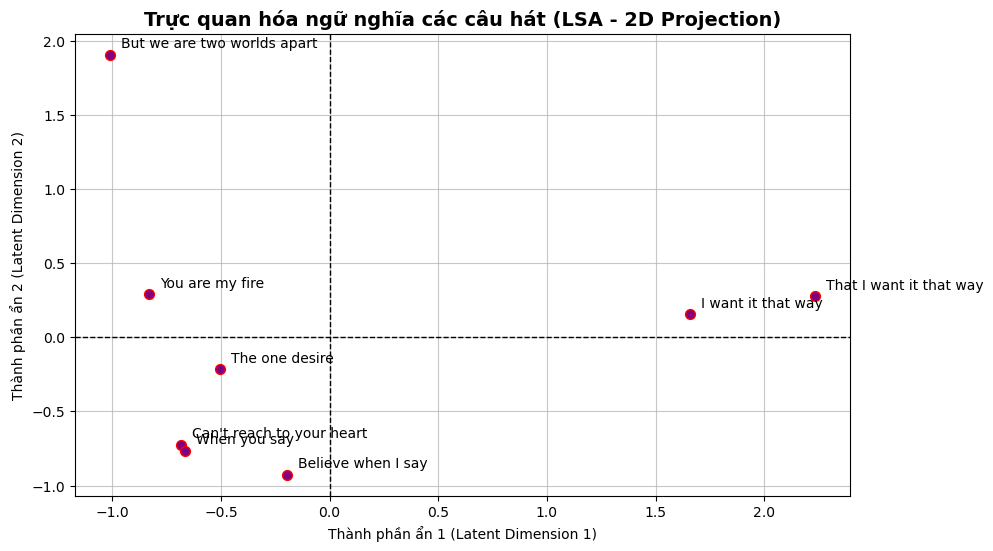

In [12]:
import matplotlib.pyplot as plt

# Tạo một khung tranh (figure) với kích thước 10x6 cho dễ nhìn
plt.figure(figsize=(10, 6))
# 1. Tách tọa độ X và Y từ biến coords (ma trận 8x2)
x = coords[:, 0]  # Lấy tất cả các hàng, cột 0 (Trục X)
y = coords[:, 1]  # Lấy tất cả các hàng, cột 1 (Trục Y)
print(f"các giá trị của x là: {x}")
print(f"các giá trị của y là: {y}")

# 2. Vẽ các điểm lên mặt phẳng (Scatter plot)
plt.scatter(x, y, color='purple', s=50, edgecolors='red', zorder=2)

# 3. Gắn nhãn (Label) cho từng điểm
for i, cau_hat in enumerate(cau):
    # plt.annotate giúp dán chữ vào cạnh cái chấm tròn
    # xytext=(8, 5) để đẩy chữ xích ra một chút cho khỏi đè lên chấm tròn
    plt.annotate(cau_hat, (x[i], y[i]), xytext=(8, 5), textcoords='offset points', fontsize=10)

# 4. Trang trí đồ thị cho chuẩn phong cách học thuật
plt.title("Trực quan hóa ngữ nghĩa các câu hát (LSA - 2D Projection)", fontsize=14, fontweight='bold')
plt.xlabel("Thành phần ẩn 1 (Latent Dimension 1)")
plt.ylabel("Thành phần ẩn 2 (Latent Dimension 2)")

# Vẽ 2 đường trục tọa độ gốc (0,0)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.axvline(0, color='black', linewidth=1, linestyle='--')

# Bật lưới cho dễ nhìn
plt.grid(True, linestyle='-', alpha=0.7, zorder=1)

# Hiển thị đồ thị
plt.show()

## 4) Nhận xét. Các câu cùng chủ đề có nằm gần nhau không? Liên hệ với eigen/PCA và “trục chính” của dữ liệu.

## 

Kết luận: CÓ. Các câu cùng chủ đề / chia sẻ chung từ vựng chắc chắn sẽ hội tụ và nằm gần nhau trên mặt phẳng 2D.


$$
\begin{aligned}
& \textbf{NHẬN XÉT VÀ LIÊN HỆ LÝ THUYẾT (PCA \& EIGENVECTORS)} \\
\\
& \textbf{1. Phân cụm ngữ nghĩa (Semantic Clustering):} \\
& \text{Dựa vào tọa độ 2D, các câu có cùng chủ đề hội tụ rất gần nhau. Ví dụ:} \\
& \bullet \text{Câu 3 \& 7 ("...want it that way"): Nằm thành cụm ở tọa độ } X > 1.5 \\
& \bullet \text{Câu 2 \& 6 ("...when...say"): Nằm thành cụm ở tọa độ } X < 0, Y < -0.7 \\
& \rightarrow \textbf{Kết luận: } \text{Khoảng cách Euclid trên mặt phẳng 2D phản ánh chính xác} \\
& \text{độ tương đồng Cosine trong không gian 25D gốc.} \\
\\
& \textbf{2. Liên hệ với PCA và Trục chính (Principal Axes):} \\
& \bullet \text{Do dữ liệu đã được Zero-mean, SVD đóng vai trò chính xác là thuật toán PCA.} \\
& \bullet \text{Hai trục tọa độ mới (X, Y) chính là 2 \textbf{Vector riêng (Eigenvectors)}} \\
& \text{ứng với 2 \textbf{Giá trị riêng (Eigenvalues)} lớn nhất của ma trận hiệp phương sai } \mathbf{X}^T\mathbf{X}\text{.} \\
& \bullet \textbf{Trục chính (Principal Axis 1 - Trục X):} \text{ Nắm giữ phương sai lớn nhất.} \\
& \text{Nó đóng vai trò phân tách rạch ròi 2 chủ đề lớn nhất của văn bản (Ví dụ: Điệp khúc} \\
& \text{mang giá trị dương lớn, các câu hát thường mang giá trị âm).} \\
& \bullet \text{Việc chiếu dữ liệu lên các Eigenvectors giúp loại bỏ nhiễu (noise), chỉ giữ lại} \\
& \text{bản chất (Latent Concepts), từ đó các câu cùng chủ đề tự động bị "hút" về gần nhau.}
\end{aligned}
$$

# Bonus: 
- Tự cài đặt bộ phân loại 1-NN (1-Nearest Neighbor) dựa trên Cosine Similarity cho dữ liệu Text.

In [13]:
def first_NN(query):
    q = to_vector(query).reshape(1,-1)
    score = cosine_similarity(q, X).flatten()
    top_i = np.argmax(score)

    res = f"score: {score[top_i]} | sentence: {cau[top_i]}"
    return res

In [14]:
print(first_NN("i want it that way"))
print(first_NN("i want your love that fire"))
print(first_NN("i fire you"))

score: 1.0 | sentence: I want it that way
score: 0.6324555320336758 | sentence: That I want it that way
score: 0.5773502691896258 | sentence: You are my fire
